# SNR-boosted scatter & regression

Sort by `x` (lower-noise axis), average consecutive blocks of `n`, then fit OLS `y ~ x` on the block means. Optional bootstrap CI on the slope.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

MATCHUP_NC = (
    "/home/zhe2/FraLab/PACE_redSIF_PACE/TROPOMI_OCI_colocation/notebooks"
    "/outputs/compare_oci_tropomi/cycle1/matchup_data.nc"
)

In [2]:
def sort_by_x_block_means(
    x: np.ndarray,
    y: np.ndarray,
    n: int = 10,
) -> tuple[np.ndarray, np.ndarray]:
    """Sort by x and return means of non-overlapping blocks of size n.

    Drops a trailing incomplete block so every mean has exactly n samples.
    """
    if n < 1:
        raise ValueError("n must be >= 1")
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)
    ok = np.isfinite(x) & np.isfinite(y)
    x, y = x[ok], y[ok]
    if x.size < n:
        raise ValueError(f"need at least n={n} finite pairs, got {x.size}")

    order = np.argsort(x, kind="mergesort")
    x, y = x[order], y[order]
    n_keep = (x.size // n) * n
    x = x[:n_keep].reshape(-1, n)
    y = y[:n_keep].reshape(-1, n)
    return x.mean(axis=1), y.mean(axis=1)


def ols_slope(x: np.ndarray, y: np.ndarray) -> tuple[float, float, float]:
    """Return (slope, intercept, Pearson r) for y = a + b x."""
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)
    if x.size < 2:
        return np.nan, np.nan, np.nan
    b, a = np.polyfit(x, y, 1)
    r = float(np.corrcoef(x, y)[0, 1])
    return float(b), float(a), r


def sort_by_x_regression(
    x: np.ndarray,
    y: np.ndarray,
    n: int = 10,
    *,
    n_boot: int = 0,
    seed: int = 0,
) -> dict:
    """Sort-by-x block average, then OLS on block means.

    Parameters
    ----------
    x, y :
        Pair samples. Prefer the lower-noise variable as ``x``.
    n :
        Block size (samples per mean). Try 10–20 for a clearer slope.
    n_boot :
        If > 0, bootstrap pairs → re-block → re-fit; returns 2.5/97.5%
        percentile CI on slope (and intercept, r).
    seed :
        RNG seed for bootstrap.

    Returns
    -------
    dict with keys:
        x_bar, y_bar, slope, intercept, r, n_blocks, block_size,
        and optionally slope_ci, intercept_ci, r_ci, slope_boot.
    """
    x_bar, y_bar = sort_by_x_block_means(x, y, n=n)
    slope, intercept, r = ols_slope(x_bar, y_bar)
    out = {
        "x_bar": x_bar,
        "y_bar": y_bar,
        "slope": slope,
        "intercept": intercept,
        "r": r,
        "n_blocks": int(x_bar.size),
        "block_size": int(n),
    }

    if n_boot > 0:
        rng = np.random.default_rng(seed)
        x0 = np.asarray(x, dtype=np.float64)
        y0 = np.asarray(y, dtype=np.float64)
        ok = np.isfinite(x0) & np.isfinite(y0)
        x0, y0 = x0[ok], y0[ok]
        slopes = np.empty(n_boot, dtype=np.float64)
        intercepts = np.empty(n_boot, dtype=np.float64)
        rs = np.empty(n_boot, dtype=np.float64)
        for i in range(n_boot):
            idx = rng.integers(0, x0.size, size=x0.size)
            xb, yb = sort_by_x_block_means(x0[idx], y0[idx], n=n)
            slopes[i], intercepts[i], rs[i] = ols_slope(xb, yb)
        out["slope_boot"] = slopes
        out["slope_ci"] = tuple(np.nanpercentile(slopes, [2.5, 97.5]))
        out["intercept_ci"] = tuple(np.nanpercentile(intercepts, [2.5, 97.5]))
        out["r_ci"] = tuple(np.nanpercentile(rs, [2.5, 97.5]))

    return out

In [3]:
ds = xr.open_dataset(MATCHUP_NC)
x = ds["sif_pace_678nm"].values.astype(np.float64)  # lower noise → x
y = ds["sif_trop_678nm"].values.astype(np.float64)  # higher noise → y

print(f"raw pairs: {np.isfinite(x).sum():,}")

BLOCK = 5
fit = sort_by_x_regression(x, y, n=BLOCK, n_boot=500, seed=0)

print(
    f"blocks={fit['n_blocks']} (n={fit['block_size']})  "
    f"slope={fit['slope']:.4f}  intercept={fit['intercept']:.4f}  R={fit['r']:.3f}"
)
print(f"slope 95% bootstrap CI: [{fit['slope_ci'][0]:.4f}, {fit['slope_ci'][1]:.4f}]")

2026-08-21 15:56:56,166 dedalus 0/1 WARNING :: Threading has not been disabled. This may massively degrade Dedalus performance.
2026-08-21 15:56:56,167 dedalus 0/1 WARNING :: We strongly suggest setting the "OMP_NUM_THREADS" environment variable to "1".
raw pairs: 1,082
blocks=216 (n=5)  slope=0.9714  intercept=-0.0239  R=0.598
slope 95% bootstrap CI: [0.7813, 1.1404]


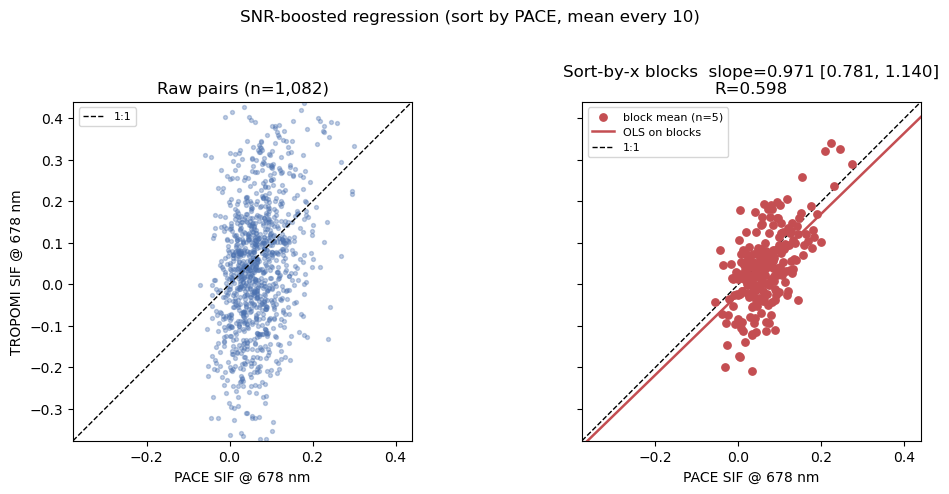

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.8), sharex=True, sharey=True)

ok = np.isfinite(x) & np.isfinite(y)
lo = float(np.nanpercentile(np.concatenate([x[ok], y[ok]]), 1))
hi = float(np.nanpercentile(np.concatenate([x[ok], y[ok]]), 99))
pad = 0.05 * (hi - lo + 1e-9)
lo, hi = lo - pad, hi + pad

ax = axes[0]
ax.scatter(x[ok], y[ok], s=8, alpha=0.35, c="#4C72B0", rasterized=True)
ax.plot([lo, hi], [lo, hi], "k--", lw=1, label="1:1")
ax.set_title(f"Raw pairs (n={ok.sum():,})")
ax.set_xlabel("PACE SIF @ 678 nm")
ax.set_ylabel("TROPOMI SIF @ 678 nm")
ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_aspect("equal", adjustable="box")
ax.legend(loc="upper left", fontsize=8)

ax = axes[1]
ax.scatter(
    fit["x_bar"], fit["y_bar"], s=28, c="#C44E52", zorder=3,
    label=f"block mean (n={BLOCK})",
)
xx = np.linspace(lo, hi, 100)
ax.plot(
    xx, fit["intercept"] + fit["slope"] * xx,
    color="#C44E52", lw=1.8, label="OLS on blocks",
)
ax.plot([lo, hi], [lo, hi], "k--", lw=1, label="1:1")
ax.set_title(
    f"Sort-by-x blocks  slope={fit['slope']:.3f} "
    f"[{fit['slope_ci'][0]:.3f}, {fit['slope_ci'][1]:.3f}]\n"
    f"R={fit['r']:.3f}"
)
ax.set_xlabel("PACE SIF @ 678 nm")
ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_aspect("equal", adjustable="box")
ax.legend(loc="upper left", fontsize=8)

fig.suptitle("SNR-boosted regression (sort by PACE, mean every 10)", y=1.02)
fig.tight_layout()
plt.show()

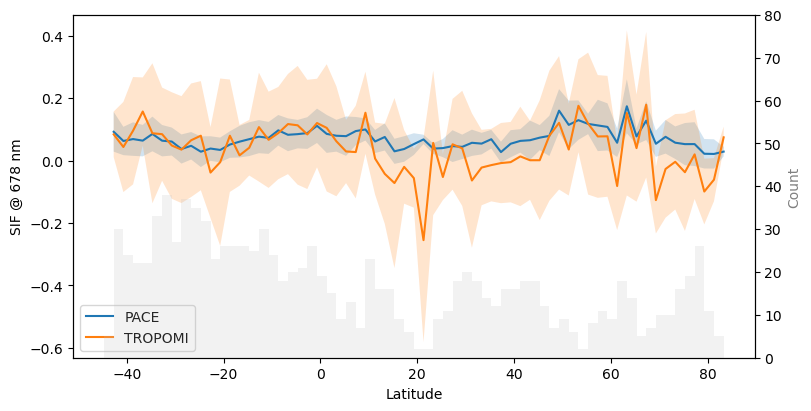

In [11]:
lat = ds["pace_lat"].values
# bin by 1˚
bin_step = 2
lat_bins = np.arange(lat.min(), lat.max() + bin_step, bin_step)
bin_index = np.digitize(lat, lat_bins)
# # plot
# plt.hist(lat, bins=lat_bins)

# take average of pace and tropomi sif by bin_index
x = ds["sif_pace_678nm"].values
y = ds["sif_trop_678nm"].values
x_bar = np.zeros(len(lat_bins))
y_bar = np.zeros(len(lat_bins))
x_std = np.zeros(len(lat_bins))
y_std = np.zeros(len(lat_bins))
for i in range(len(lat_bins)):
    x_bar[i] = np.mean(x[bin_index == i])
    y_bar[i] = np.mean(y[bin_index == i])
    x_std[i] = np.std(x[bin_index == i])
    y_std[i] = np.std(y[bin_index == i])

# plot scatter plot of x_bar and y_bar
# plt.plot(lat_bins, x_bar)
# plt.plot(lat_bins, y_bar)
# plt.xlabel("PACE SIF @ 678 nm")
# plt.ylabel("TROPOMI SIF @ 678 nm")
# plt.show()

fig, ax = plt.subplots(figsize=(8, 4), layout="constrained", sharex=True)
ax.plot(lat_bins, x_bar)
ax.plot(lat_bins, y_bar)
ax.fill_between(lat_bins, x_bar - x_std, x_bar + x_std, alpha=0.2)
ax.fill_between(lat_bins, y_bar - y_std, y_bar + y_std, alpha=0.2)
ax.set_xlabel("Latitude")
ax.set_ylabel("SIF @ 678 nm")
ax.legend(["PACE", "TROPOMI"])

ax1 = ax.twinx()
ax1.hist(lat, bins=lat_bins, color="silver", alpha=0.2)
ax1.set_ylim(0, 80)
ax1.set_xlabel("Latitude")
ax1.set_ylabel("Count", color="grey")

plt.show()
